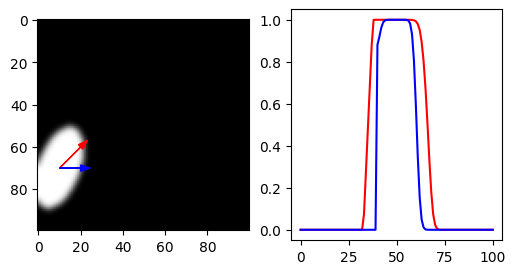

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.measure import profile_line

def calculate_vector_intensity(image, centroid, vector, linewidth=1, linelength=200):
    """Calculates the intensity profile and total sum along a vector starting from a centroid.

    Parameters:
    -----------
    image : 2D numpy array
        The image (e.g., your membrane frame).
    centroid : tuple or list (x, y)
        The starting point of your measurement.
    vector : tuple or list (dx, dy)
        The direction and length you want to measure.
    linewidth : int
        Width of the line to sample. If > 1, it averages pixels
        perpendicular to the line (great for reducing noise).
    linelength : int
        The length of the line to sample.

    Returns:
    --------
    total_sum : float
        The sum of intensities along the vector.
    profile : 1D numpy array
        The raw intensity values along the line from start to finish.
    """
    x0, y0 = centroid
    dx, dy = vector
    # Normalize the vector to 1 and then scale to desired length
    norm = np.sqrt(dx**2 + dy**2)
    dx = dx/norm
    dy = dy/norm

    # 1. Calculate the end point of the vector
    x1, y1 = x0 + dx*linelength/2, y0 + dy*linelength/2
    x0, y0 = x0 - dx*linelength/2, y0 - dy*linelength/2  # Start point is also shifted back to keep the centroid in the middle

    # 2. Extract the intensity profile
    # WARNING: profile_line expects coordinates as (row, col), which corresponds to (y, x)!
    profile = profile_line(
        image, (y0, x0), (y1, x1), linewidth=linewidth, mode="constant", cval=0
    )

    # 3. Calculate the sum
    total_sum = np.sum(profile)

    return total_sum, profile

def make_elipse_image(img_size=(100, 100), centroid=(50, 50), orientation=0, r1=10, r2=20):
    """
    Generates a test image containing a soft-edged rotated ellipse.
    
    Parameters:
    -----------
    img_size : tuple (height, width)
        Size of the output image.
    centroid : tuple (x, y)
        The center coordinate of the ellipse.
    orientation : float
        The rotation angle in degrees (counter-clockwise).
    r1 : float
        The radius along the primary axis (maps to X at 0 deg).
    r2 : float
        The radius along the secondary axis (maps to Y at 0 deg).
    """
    height, width = img_size
    x_c, y_c = centroid
    
    # 1. Create a coordinate grid
    y_grid, x_grid = np.ogrid[:height, :width]
    
    # 2. Shift the grid origin to the centroid
    dx = x_grid - x_c
    dy = y_grid - y_c
    
    # 3. Convert orientation from degrees to radians
    theta = np.deg2rad(orientation)
    
    # 4. Apply the rotation matrix to find the "local" ellipse coordinates
    # This rotates the grid points in the opposite direction of the ellipse's orientation
    x_rotated = dx * np.cos(theta) + dy * np.sin(theta)
    y_rotated = -dx * np.sin(theta) + dy * np.cos(theta)
    
    # Avoid division by zero
    if r1 == 0 or r2 == 0:
        return np.zeros(img_size)

    # 5. Calculate the standard ellipse equation on the rotated coordinates
    dist_sq = (x_rotated / r1)**2 + (y_rotated / r2)**2
    mask = dist_sq <= 1.0
    
    # Convert boolean to float and apply a light blur for microscopy realism
    img = mask.astype(float)
    img = gaussian_filter(img, sigma=1.5)
    
    # Normalize to 0-1
    if img.max() > 0:
        img /= img.max()
        
    return img

centroid = (10, 70)
img = make_elipse_image(centroid=centroid, orientation=20, r1=10, r2=20)

fig, axes = plt.subplots(1,2,figsize=(6,3))
axes[0].imshow(img, cmap='gray')

vec_0 = (10,-10)  # Example vector pointing to the right
vec_1 = (10,0)   # Example vector pointing down
# Show the vector in the image
axes[0].arrow(centroid[0], centroid[1], vec_0[0], vec_0[1], color='red', head_width=3)
axes[0].arrow(centroid[0], centroid[1], vec_1[0], vec_1[1], color='blue', head_width=3)

# Get the intensity profile along the vector
total_sum, profile = calculate_vector_intensity(img, centroid=centroid, vector=vec_0, linewidth=5, linelength=100)
total_sum_1, profile_1 = calculate_vector_intensity(img, centroid=centroid, vector=vec_1, linewidth=5, linelength=100)

axes[1].plot(profile, color='red')
axes[1].plot(profile_1, color='blue')